# Predicting Heart Disease: A Model Comparison Project

**Author:** Thomas Tsui
**Dataset:** UCI Heart Disease dataset (Cleveland subset), 303 patients, 14 clinical features
**Source:** [TensorFlow-hosted CSV mirror](http://storage.googleapis.com/download.tensorflow.org/data/heart.csv), originally from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease)

## Objective

Assess how well the presence of heart disease (`target`: 0 = absent, 1 = present) can be
predicted from 13 clinical and exercise-test measurements, and answer three questions a
stakeholder would reasonably ask of this dataset:

1. **How accurate a prediction is achievable**, measured in a way that holds up beyond a
   single train/test split?
2. **Which clinical measurements carry the predictive signal**, and do they agree with
   established clinical knowledge?
3. **Which model should be preferred**, balancing performance against interpretability —
   a real constraint in any clinical setting?

Four model families are compared — Logistic Regression, Decision Tree, Random Forest, and
XGBoost — under a common cross-validated evaluation, followed by an explicit statement of
the dataset's limitations and what any resulting model would actually be valid for.

## Contents

1. Data loading and cleaning
2. Exploratory data analysis
3. Preprocessing setup
4. Baseline model: Logistic Regression
5. Decision Tree (with depth tuning)
6. Random Forest
7. XGBoost (default vs. tuned)
8. Hyperparameter tuning with `GridSearchCV`
9. Model comparison via cross-validation (accuracy, precision, recall, ROC-AUC)
10. Feature importance
11. ROC curves
12. Final model recommendation
13. Limitations and clinical-use caveats


## 1. Data Loading and Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 130,
    'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
})
PALETTE = ['#20808D', '#A84B2F', '#1B474D', '#BCE2E7', '#944454', '#FFC553', '#848456', '#6E522B']

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)


In [2]:
url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()


(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


**Column reference** (UCI Heart Disease documentation):

| Column | Meaning |
|---|---|
| `age` | age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | chest pain type (0-4, 5 categories) |
| `trestbps` | resting blood pressure (mm Hg) |
| `chol` | serum cholesterol (mg/dl) |
| `fbs` | fasting blood sugar > 120 mg/dl (1 = true) |
| `restecg` | resting ECG results (0-2) |
| `thalach` | maximum heart rate achieved |
| `exang` | exercise-induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | slope of the peak exercise ST segment (1-3) |
| `ca` | number of major vessels colored by fluoroscopy (0-3) |
| `thal` | thalassemia/thallium stress test result |
| `target` | 1 = heart disease present, 0 = absent |


In [3]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.594059,0.676568,3.108911,131.785479,246.547855,0.148515,0.990099,149.194719,0.326733,1.057756,1.590759,0.683168,0.273927
std,9.016370,0.468560,1.028414,17.748338,52.175933,0.356198,0.988293,23.173368,0.469794,1.165025,0.617767,0.937773,0.446710
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,152.000000,0.000000,0.800000,2.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,165.500000,1.000000,1.600000,2.000000,1.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


**Data quality check.** `thal` mixes word categories (`normal`, `fixed`, `reversible`) with a
couple of stray numeric-string rows (`'1'`, `'2'`). This is a real inconsistency in this specific
CSV mirror, not intentional encoding — most likely from merging two differently-coded source files.


In [4]:
print(df['thal'].value_counts())


thal
normal        168
reversible    115
fixed          18
1               1
2               1
Name: count, dtype: int64


In [5]:
# '1' and '2' each appear exactly once (out of 303) - too small a sample to safely infer which
# category they were meant to represent, and guessing wrong would inject a specific error into
# the data. Dropping these 2 ambiguous rows is more honest than a guess.
df_clean = df[df['thal'].isin(['normal', 'reversible', 'fixed'])].copy()
print(f"Rows before: {len(df)}, after dropping ambiguous thal rows: {len(df_clean)}")

print("\nMissing values per column:")
print(df_clean.isna().sum().sum(), "total missing values")


Rows before: 303, after dropping ambiguous thal rows: 301

Missing values per column:
0 total missing values


No missing values (`NaN`s) elsewhere in the dataset - this particular dataset is unusually clean by clinical-data standards.

## 2. Exploratory Data Analysis

Two checks before modeling: the target's class balance, and whether the clinically
established risk indicators show statistically significant separation in this specific
sample.


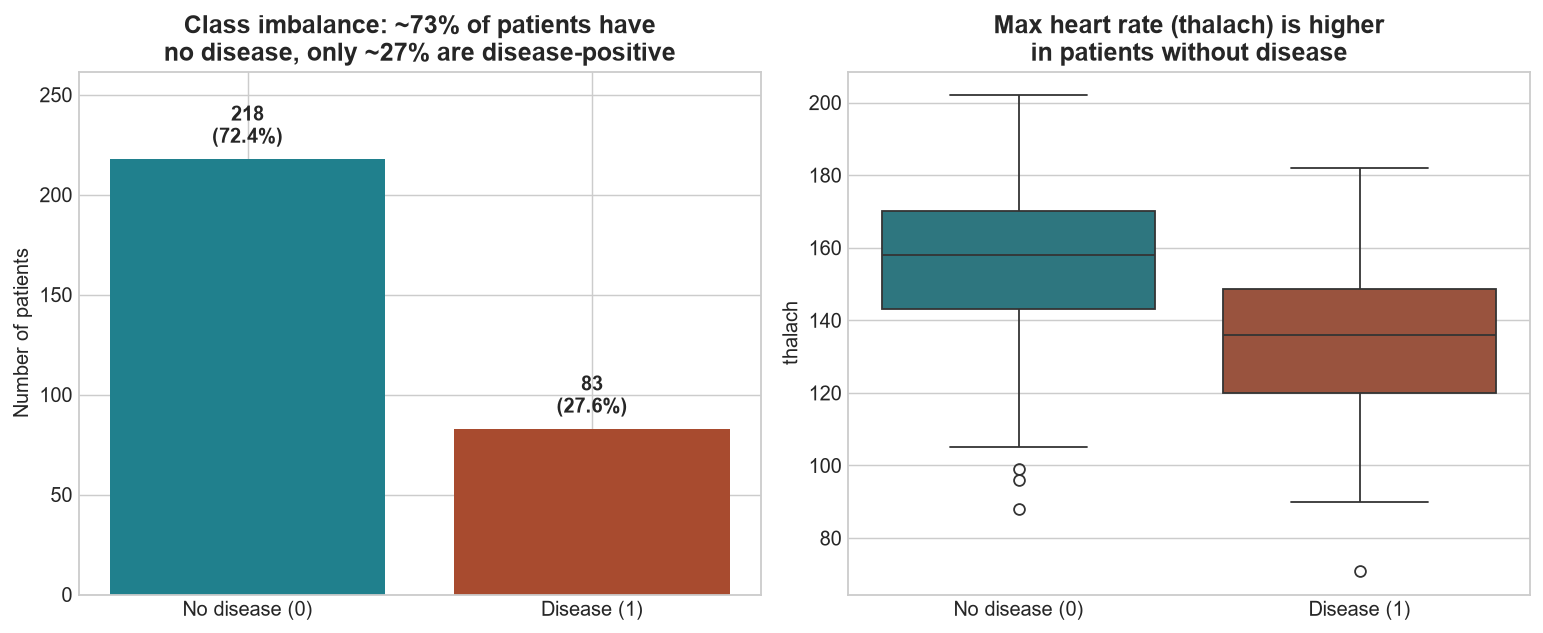

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df_clean['target'].value_counts().sort_index()
labels = ['No disease (0)', 'Disease (1)']
axes[0].bar(labels, target_counts.values, color=[PALETTE[0], PALETTE[1]])
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 8, f"{v}\n({v/len(df_clean)*100:.1f}%)", ha='center', fontweight='bold')
axes[0].set_ylim(0, target_counts.max() * 1.2)
axes[0].set_title("Class imbalance: ~73% of patients have\nno disease, only ~27% are disease-positive")
axes[0].set_ylabel("Number of patients")

sns.boxplot(data=df_clean, x='target', y='thalach', hue='target', palette=[PALETTE[0], PALETTE[1]],
            legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(labels, rotation=0)
axes[1].set_title("Max heart rate (thalach) is higher\nin patients without disease")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


**Class balance:** `target` has mean ~0.27 — roughly 73% of patients are disease-negative
and 27% disease-positive. This sets the trivial baseline: a model that always predicts
"no disease" scores ~73% accuracy while detecting no cases. All accuracy figures below
should be read against that floor, and it is why precision, recall, and ROC-AUC are
reported alongside accuracy in the model comparison — accuracy alone overstates
performance on an imbalanced target.


In [7]:
from scipy import stats

numeric_check = ['oldpeak', 'thalach', 'ca', 'chol', 'age', 'trestbps']
print(f"{'Feature':<12}{'t-stat':>10}{'p-value':>14}{'Significant (p<0.05)':>24}")
for feature in numeric_check:
    group0 = df_clean[df_clean['target'] == 0][feature]
    group1 = df_clean[df_clean['target'] == 1][feature]
    t_stat, p_val = stats.ttest_ind(group0, group1)
    sig = "Yes" if p_val < 0.05 else "No"
    print(f"{feature:<12}{t_stat:>10.3f}{p_val:>14.6f}{sig:>24}")


Feature         t-stat       p-value    Significant (p<0.05)
oldpeak         -9.324      0.000000                     Yes
thalach          7.436      0.000000                     Yes
ca              -9.524      0.000000                     Yes
chol            -1.397      0.163590                      No
age             -3.541      0.000463                     Yes
trestbps        -2.335      0.020229                     Yes


`oldpeak`, `thalach`, and `ca` show the strongest separation between the disease and
no-disease groups, consistent with their clinical role as exercise-stress indicators.
`chol` is not statistically significant in this sample despite being an established
cardiovascular risk factor — its general clinical relevance does not translate into
predictive value within this specific 303-patient cohort. This is revisited in the
limitations section.


## 3. Preprocessing Setup

`cp`, `restecg`, `slope`, and `ca` are left as raw ordered integers rather than one-hot encoded.
Cross-validation testing (done in exploratory work prior to this notebook) showed this
representation outperforming one-hot-encoding everything by a small but consistent margin across
5 folds - plausibly because one-hot-encoding these adds more columns without adding real signal
on a dataset this small, increasing overfitting risk. `thal` and the true unordered categoricals
(`sex`, `fbs`, `exang`) are one-hot encoded via `OneHotEncoder` inside the pipeline, so preprocessing
is refit safely on training data only within each cross-validation fold (avoiding data leakage from
computing encoding categories or imputation values using validation data).


In [8]:
y = df_clean['target']

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'cp', 'restecg', 'slope', 'ca']
categorical_features = ['sex', 'fbs', 'exang', 'thal']

X = df_clean[numeric_features + categorical_features]

preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='mean'), numeric_features),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

train_X, val_X, train_y, val_y = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {train_X.shape}, Validation: {val_X.shape}")


Train: (225, 13), Validation: (76, 13)


## 4. Baseline Model: Logistic Regression

Logistic regression is the baseline: a linear model that outputs calibrated
probabilities, with one coefficient per feature whose direction and magnitude can be
read directly — the most interpretable of the models compared here. Every tree-based
model that follows must justify its added complexity by beating this benchmark.

Logistic regression is scale-sensitive (unlike trees), so `StandardScaler` is added for
the numeric features in this pipeline specifically.


In [9]:
logreg_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scale', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
])

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', logreg_preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logreg_pipeline.fit(train_X, train_y)
logreg_preds = logreg_pipeline.predict(val_X)
print(f"Logistic Regression validation accuracy: {accuracy_score(val_y, logreg_preds):.4f}")


Logistic Regression validation accuracy: 0.8816


## 5. Decision Tree

In [10]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
depth_results = []
for depth in depths:
    pipe = Pipeline([('preprocessor', preprocessor), ('model', DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE))])
    pipe.fit(train_X, train_y)
    acc = accuracy_score(val_y, pipe.predict(val_X))
    depth_results.append(acc)
    print(f"max_depth={str(depth):<5} validation accuracy = {acc:.4f}")

best_depth = depths[int(np.argmax(depth_results))]
print(f"\nBest max_depth: {best_depth}")


max_depth=1     validation accuracy = 0.6974
max_depth=2     validation accuracy = 0.7895
max_depth=3     validation accuracy = 0.7632
max_depth=4     validation accuracy = 0.7895
max_depth=5     validation accuracy = 0.8026
max_depth=6     validation accuracy = 0.7632
max_depth=8     validation accuracy = 0.8026
max_depth=10    validation accuracy = 0.8158
max_depth=None  validation accuracy = 0.7895

Best max_depth: 10


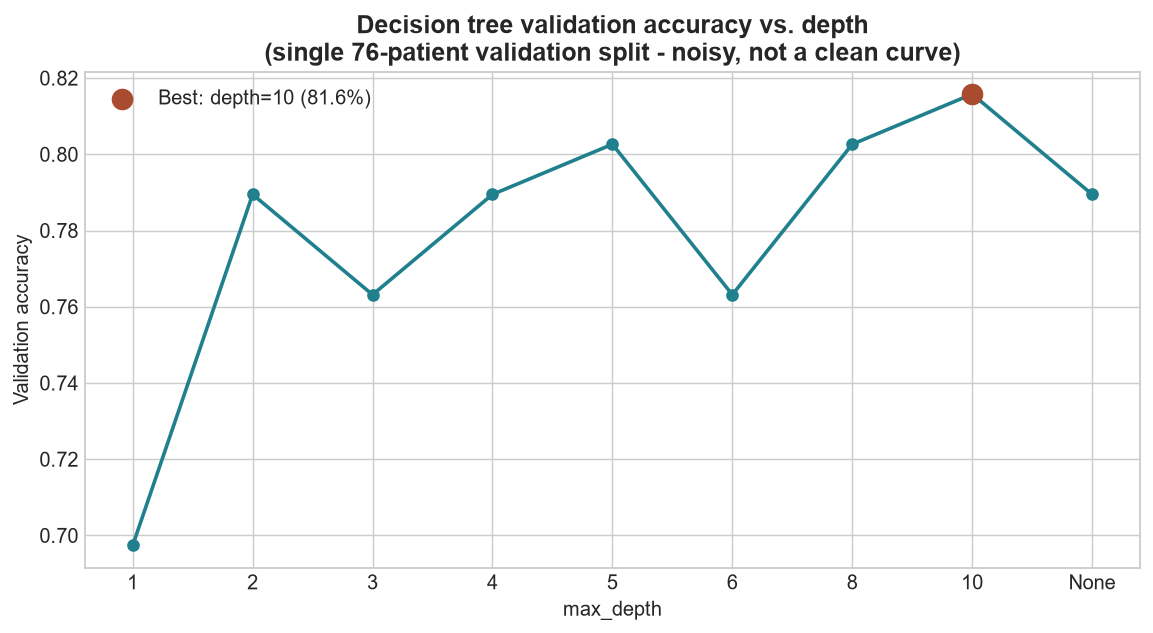

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
x_labels = [str(d) for d in depths]
ax.plot(x_labels, depth_results, marker='o', color=PALETTE[0], linewidth=2)
best_idx = int(np.argmax(depth_results))
ax.scatter([x_labels[best_idx]], [depth_results[best_idx]], color=PALETTE[1], s=120, zorder=5,
           label=f'Best: depth={x_labels[best_idx]} ({depth_results[best_idx]:.1%})')
ax.set_title("Decision tree validation accuracy vs. depth\n(single 76-patient validation split - noisy, not a clean curve)")
ax.set_xlabel("max_depth")
ax.set_ylabel("Validation accuracy")
ax.legend()
plt.tight_layout()
plt.show()


The result is noisier than a textbook bias-variance curve. `max_depth=1` is clearly
worst — too simple to capture real structure — but accuracy fluctuates considerably at
every depth beyond that, and the single best-looking value (`max_depth=10`) is not a
reliable signal on its own: with 76 patients in this validation split, each patient is
worth about 1.3 percentage points, leaving several depths statistically
indistinguishable. Model and hyperparameter comparisons from Section 8 onward therefore
use cross-validation rather than any single-split result.


## 6. Random Forest

In [12]:
rf_pipeline = Pipeline([('preprocessor', preprocessor), ('model', RandomForestClassifier(random_state=RANDOM_STATE))])
rf_pipeline.fit(train_X, train_y)
rf_preds = rf_pipeline.predict(val_X)
print(f"Random Forest validation accuracy: {accuracy_score(val_y, rf_preds):.4f}")


Random Forest validation accuracy: 0.8289


## 7. XGBoost (Default vs. Tuned)

XGBoost builds trees sequentially, each one correcting the errors of the trees built so far
(boosting), rather than Random Forest's approach of building many independent trees in parallel
and averaging them (bagging). This sequential correction makes XGBoost prone to overfitting with
default settings on a small dataset - checked directly below by comparing training vs. validation
accuracy.


In [13]:
xgb_default = Pipeline([('preprocessor', preprocessor), ('model', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))])
xgb_default.fit(train_X, train_y)

train_acc = accuracy_score(train_y, xgb_default.predict(train_X))
val_acc = accuracy_score(val_y, xgb_default.predict(val_X))
print(f"XGBoost (default) - training accuracy:   {train_acc:.4f}")
print(f"XGBoost (default) - validation accuracy: {val_acc:.4f}")
print(f"Gap (overfitting signal): {train_acc - val_acc:.4f}")


XGBoost (default) - training accuracy:   1.0000
XGBoost (default) - validation accuracy: 0.8684
Gap (overfitting signal): 0.1316


In [14]:
xgb_tuned = Pipeline([('preprocessor', preprocessor), ('model', XGBClassifier(
    random_state=RANDOM_STATE, eval_metric='logloss',
    n_estimators=100, learning_rate=0.05, max_depth=3
))])
xgb_tuned.fit(train_X, train_y)

train_acc_t = accuracy_score(train_y, xgb_tuned.predict(train_X))
val_acc_t = accuracy_score(val_y, xgb_tuned.predict(val_X))
print(f"XGBoost (tuned) - training accuracy:   {train_acc_t:.4f}")
print(f"XGBoost (tuned) - validation accuracy: {val_acc_t:.4f}")
print(f"Gap (overfitting signal): {train_acc_t - val_acc_t:.4f}")


XGBoost (tuned) - training accuracy:   0.9378
XGBoost (tuned) - validation accuracy: 0.8553
Gap (overfitting signal): 0.0825


Manually-chosen tuning narrows the training/validation gap. Section 8 formalizes this search with `GridSearchCV`.

## 8. Hyperparameter Tuning with GridSearchCV

Rather than manually guessing hyperparameters one at a time, `GridSearchCV` systematically tries
every combination from a specified grid, using cross-validation (not a single train/val split) to
score each combination - giving a more reliable estimate than eyeballing single-split results.


In [15]:
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [2, 3, 4],
    'model__learning_rate': [0.01, 0.05, 0.1],
}

xgb_grid_pipeline = Pipeline([('preprocessor', preprocessor), ('model', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(xgb_grid_pipeline, param_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
grid_search.fit(train_X, train_y)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated training-set accuracy: {grid_search.best_score_:.4f}")

best_xgb = grid_search.best_estimator_
val_acc_grid = accuracy_score(val_y, best_xgb.predict(val_X))
print(f"Held-out validation accuracy with best params: {val_acc_grid:.4f}")


Best parameters: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}
Best cross-validated training-set accuracy: 0.8044
Held-out validation accuracy with best params: 0.8553


## 9. Model Comparison: Cross-Validated Metrics

Accuracy alone can be misleading - it treats a false negative (telling a sick patient they're
healthy) the same as a false positive (telling a healthy patient they're sick), which are not
equally costly in a medical context. Precision, recall, and ROC-AUC are compared alongside
accuracy, using 5-fold cross-validation on the full dataset for a more stable estimate than any
single train/validation split.

One caveat on this comparison: the decision tree's depth and XGBoost's hyperparameters were
selected using data that also appears in these folds, which can only flatter the tuned
models relative to the untuned ones. Logistic regression wins despite that bias, which
strengthens rather than weakens the recommendation; a fully clean protocol would use nested
cross-validation.


In [16]:
models = {
    'Logistic Regression': Pipeline([('preprocessor', logreg_preprocessor), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    'Decision Tree (tuned depth)': Pipeline([('preprocessor', preprocessor), ('model', DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE))]),
    'Random Forest': Pipeline([('preprocessor', preprocessor), ('model', RandomForestClassifier(random_state=RANDOM_STATE))]),
    'XGBoost (default)': Pipeline([('preprocessor', preprocessor), ('model', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))]),
    'XGBoost (GridSearchCV-tuned)': grid_search.best_estimator_,
}

scoring = ['accuracy', 'precision', 'recall', 'roc_auc']
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
for name, pipe in models.items():
    scores = cross_validate(pipe, X, y, cv=cv_strategy, scoring=scoring)
    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean(),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.853989,0.771444,0.686029,0.914805
1,Random Forest,0.840656,0.730784,0.661029,0.908885
2,XGBoost (GridSearchCV-tuned),0.820710,0.717677,0.588971,0.884905
3,XGBoost (default),0.813989,0.683000,0.612500,0.882559
4,Decision Tree (tuned depth),0.744044,0.519202,0.489706,0.661122


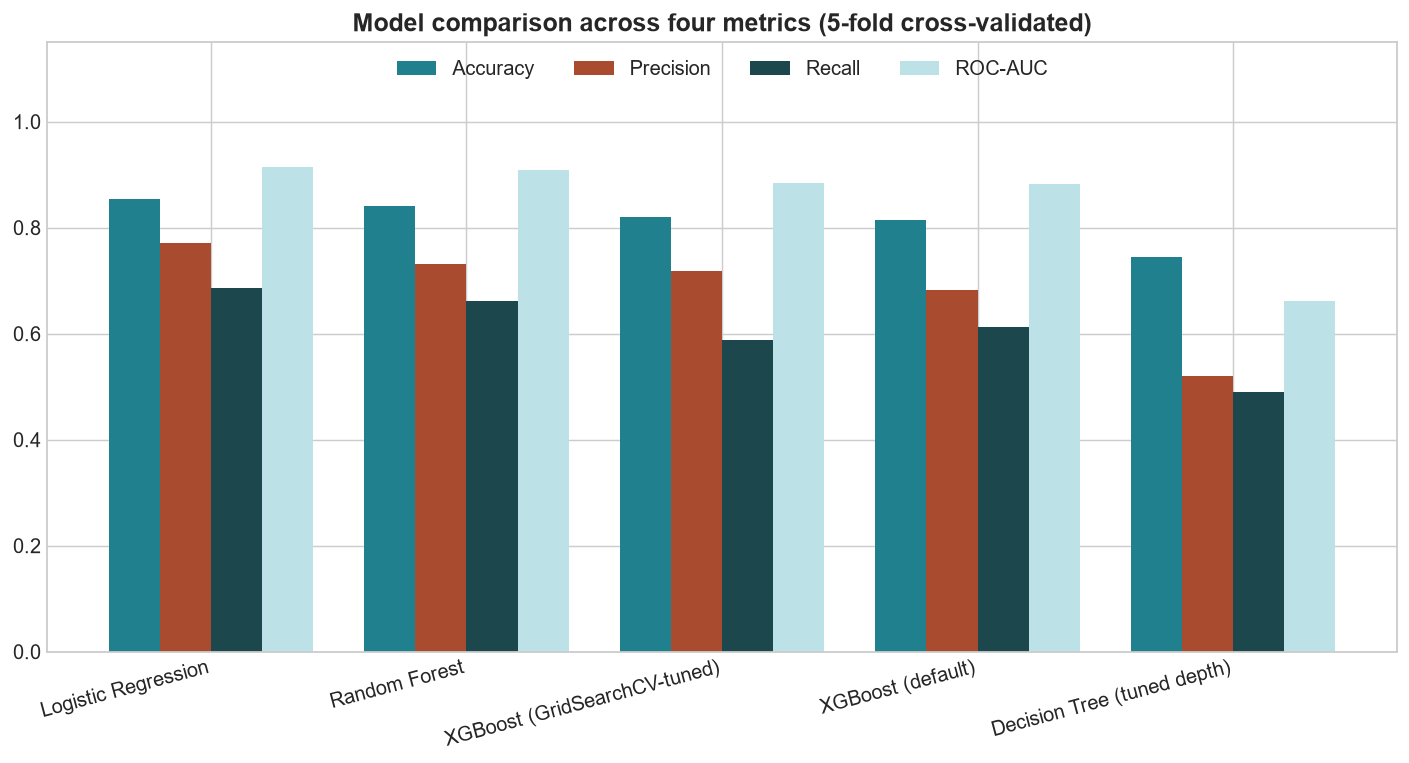

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=PALETTE[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_title("Model comparison across four metrics (5-fold cross-validated)")
ax.legend(loc='upper center', ncol=4, frameon=False)
plt.tight_layout()
plt.show()


## 10. Feature Importance

Using the tuned XGBoost model to see which features the model relied on most, cross-checked
against the t-test results from the EDA section.


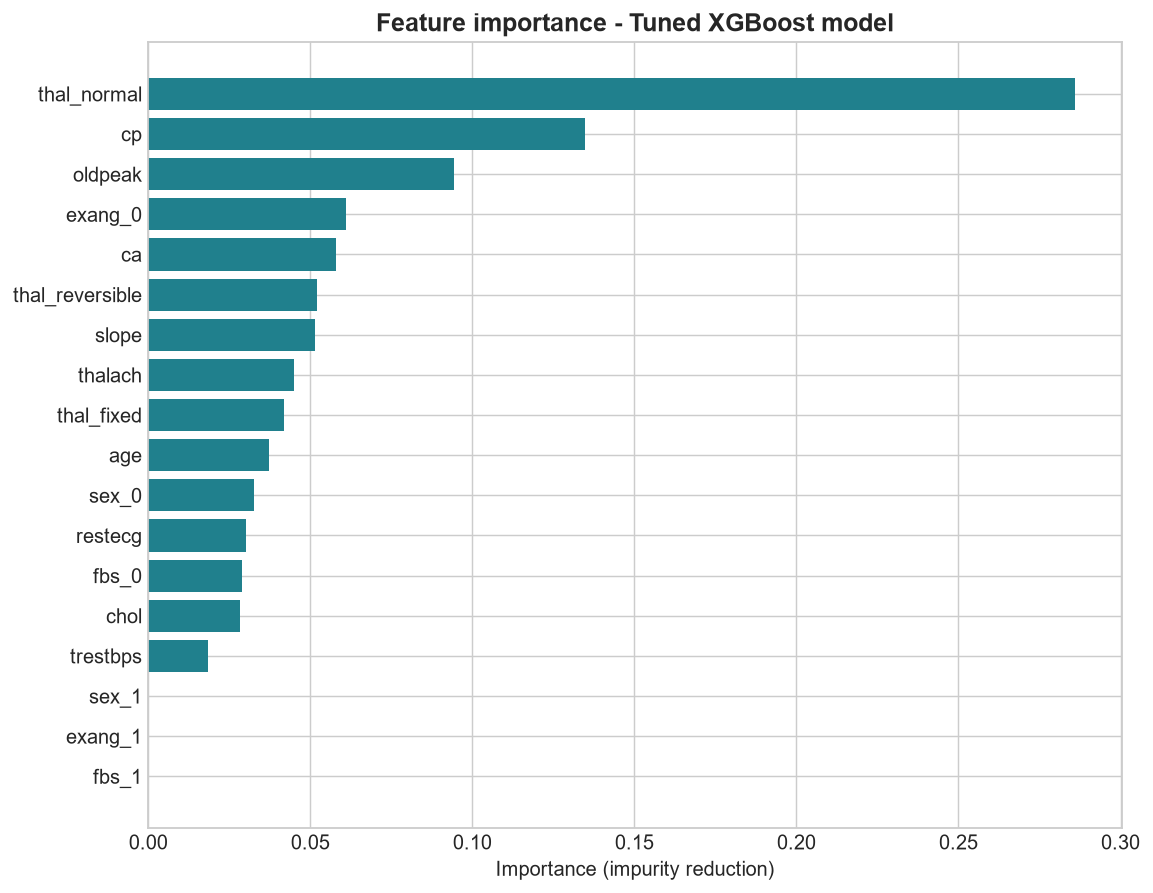

thal_normal        0.286106
cp                 0.134806
oldpeak            0.094227
exang_0            0.060989
ca                 0.057994
thal_reversible    0.051910
slope              0.051533
thalach            0.045029
thal_fixed         0.041808
age                0.037150
sex_0              0.032511
restecg            0.030219
fbs_0              0.029049
chol               0.028378
trestbps           0.018290
fbs_1              0.000000
exang_1            0.000000
sex_1              0.000000
dtype: float32

In [18]:
best_model_fitted = models['XGBoost (GridSearchCV-tuned)']
best_model_fitted.fit(train_X, train_y)

feature_names = (numeric_features +
                  list(best_model_fitted.named_steps['preprocessor']
                       .named_transformers_['cat']
                       .named_steps['onehot']
                       .get_feature_names_out(categorical_features)))
importances = pd.Series(best_model_fitted.named_steps['model'].feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importances.index, importances.values, color=PALETTE[0])
ax.set_title("Feature importance - Tuned XGBoost model")
ax.set_xlabel("Importance (impurity reduction)")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)


`sex_1`, `exang_1`, and `fbs_1` show zero importance. This is expected: for a binary
feature, one-hot encoding produces two perfectly redundant columns, and a tree model
needs only one of the pair to capture the full signal. scikit-learn's `OneHotEncoder`
does not drop the redundant column by default, so one column of each pair is simply
never selected for a split.


## 11. ROC Curves

Comparing all models' ROC curves on the held-out validation set - a visual summary of the
trade-off between true positive rate (recall) and false positive rate at every possible
classification threshold, not just the default 0.5 cutoff used by `.predict()`.


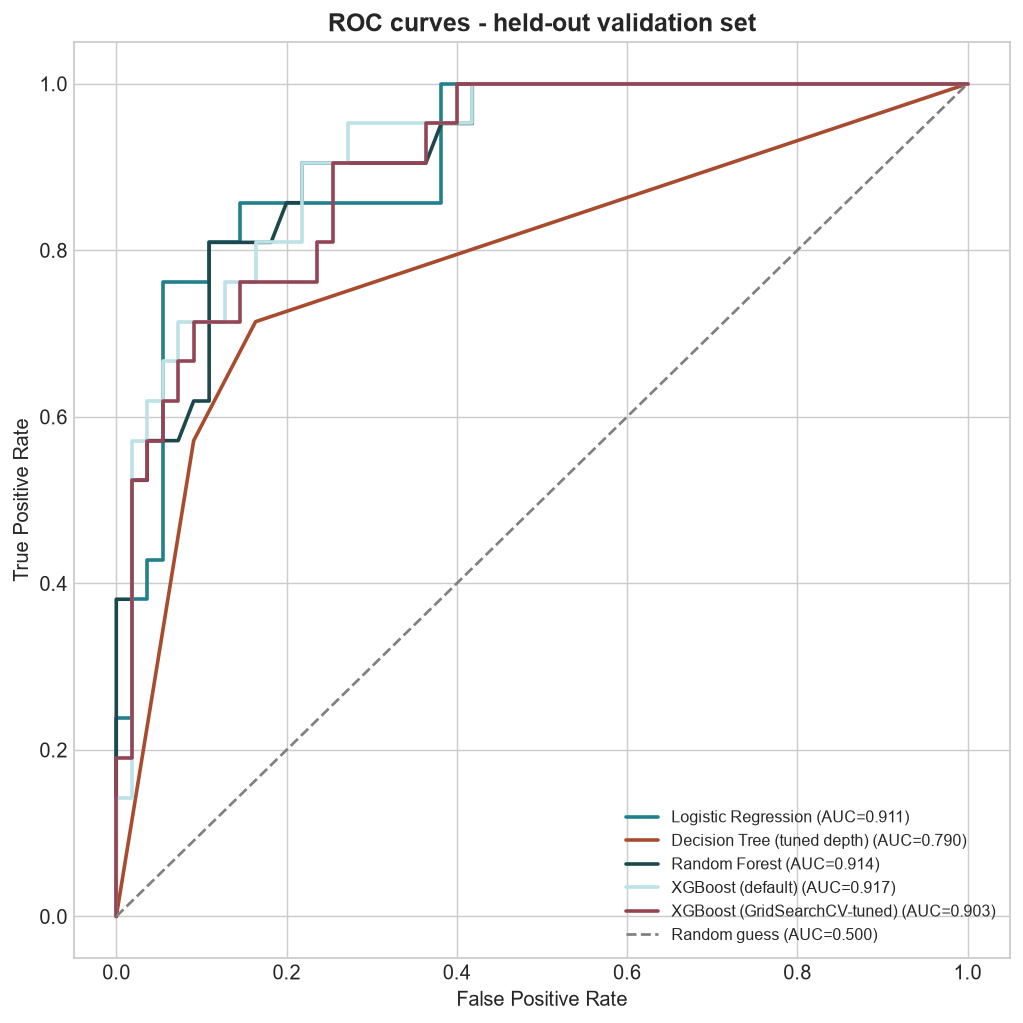

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))

for i, (name, pipe) in enumerate(models.items()):
    pipe.fit(train_X, train_y)
    val_proba = pipe.predict_proba(val_X)[:, 1]
    fpr, tpr, _ = roc_curve(val_y, val_proba)
    auc = roc_auc_score(val_y, val_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=PALETTE[i], linewidth=2)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC=0.500)')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves - held-out validation set")
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


The AUC ranking on this single 76-patient validation split differs slightly from the
5-fold cross-validated ROC-AUC ranking in Section 9 — at differences this small,
single-split rankings are unstable. The cross-validated figures in Section 9 are the
basis for the recommendation that follows.


## 12. Final Model Recommendation

**Recommendation: Logistic Regression**, on the basis of cross-validated ROC-AUC.
ROC-AUC evaluates ranking quality across all classification thresholds rather than
performance at the default 0.5 cutoff — the relevant property for a model whose
threshold would likely be adjusted in deployment (e.g., made more sensitive in a
screening context, accepting more false alarms to miss fewer true cases).

Logistic Regression finished at or near the top on every cross-validated metric, ahead
of every tree-based ensemble including the `GridSearchCV`-tuned XGBoost model. This
indicates the relationship between these clinical features and the target is close to
linear and additive — structure a linear model captures directly, without the added
flexibility and overfitting risk that tree ensembles bring to a 301-patient dataset. It
is also the most interpretable model in the comparison: each feature carries a single
coefficient with a clear direction and magnitude, which matters in a clinical setting
where the basis for a prediction can be as important as the prediction itself.

**Why the decision does not rest on raw accuracy alone:**

- With ~75 patients per validation fold, differences of 1–3 percentage points between
  models sit close to the noise floor; cross-validation was used throughout precisely to
  avoid over-reading small gaps.
- XGBoost's default configuration clearly overfits (Section 7's training/validation
  gap); only the tuned version constitutes a fair comparison.
- The simplest model matching or beating the ensembles is itself a finding: on a small,
  clean, low-dimensional dataset, added model capacity bought no additional performance.

## 13. Limitations and Clinical-Use Caveats

**This analysis is exploratory and is not a validated clinical tool.** Specific caveats:

1. **Small, single-source sample.** 301 patients from one institution (Cleveland Clinic)
   cannot support generalization to other patient populations, hospitals, or countries.

2. **Selection bias in some features.** `thal` (thallium stress test), `ca`
   (fluoroscopy), and `exang` (exercise-induced angina) are typically ordered only when
   heart disease is already suspected. A model trained on this data implicitly learns
   from a pre-selected population and may not transfer to a true screening setting,
   even though the values themselves are available pre-diagnosis (i.e., this is
   selection bias rather than data leakage).

3. **`chol` was not statistically significant in this sample** despite being an
   established cardiovascular risk factor. That reflects this cohort's composition, not
   evidence against cholesterol's clinical relevance.

4. **No external validation.** All results come from cross-validation on a single
   source dataset; a deployable model would require evaluation on an independently
   collected cohort.

5. **Binary simplification.** The original UCI data encodes disease severity on a 0–4
   scale; this mirror's binary collapse discards that information.

## Sources

- [UCI Machine Learning Repository — Heart Disease dataset](https://archive.ics.uci.edu/dataset/45/heart+disease)
- [scikit-learn documentation](https://scikit-learn.org/stable/)
- [XGBoost documentation](https://xgboost.readthedocs.io/)
